# OS Notebook
# P2: Text Preprocessing
# Web Mining and Applied NLP

REQ: Open notebooks with a standard header including a good title, your company/name/alias, a link to the repo, purpose, and date.

- Author: [Oluwafemi Salawu](https://github.com/Airfirm)
- Repository: [nlp-02-text-preprocessing](https://github.com/Airfirm/nlp-02-text-preprocessing)
- Purpose: Read text data, preprocess the text, compare raw and cleaned tokens, summarize the results, and answer additional business questions.
- Date: 2026-03-14

# New Analytical Questions

- What topics or themes appear most often?
- What common 2-word phrases appear in the text?
- How repetitive or diverse is the vocabulary?
- Which records are unusually short or long?
- Which business-related categories are mentioned most?

## Section 1. Setup and Imports

Imports and configuration appear once, at the top.

WHY:
- Keeps notebooks readable and reproducible
- Mirrors professional scripts
- Makes requirements clear

In [1]:
# Section 1 Setup and Imports.

# Imports at the top of the file
# REQ: External packages must be defined in pyproject.toml
# REQ: External packages must be installed in the environment using `uv sync` command
# REQ: External packages used in this notebook must be imported here

from collections import Counter
from pathlib import Path
import re

import matplotlib.pyplot as plt
import polars as pl

print("Imports complete.")

Imports complete.


## Section 2. Read the Text Data

In [2]:
# Section 2 Python cell

# In notebooks, start with the current working directory
# where the notebook is located.
NOTEBOOKS_PATH: Path = Path.cwd()
ROOT_PATH: Path = NOTEBOOKS_PATH.parent

DATA_PATH: Path = ROOT_PATH / "data"
NOTEBOOKS_PATH: Path = ROOT_PATH / "notebooks"
SCRIPTS_PATH: Path = ROOT_PATH / "scripts"

# Choose a text file to analyze.
# Each line is treated as one text record.
input_path: Path = DATA_PATH / "text_data_femi.txt"

# Read all lines from the file.
text_list: list[str] = input_path.read_text(encoding="utf-8").splitlines()

# Remove blank lines.
text_list = [line.strip() for line in text_list if line.strip()]

print("Data loaded successfully.")
print(f"Loaded {len(text_list):,} text records.")

# Combine all text rows into one large string for simple preprocessing.
raw_text: str = " ".join(text_list)

print(f"Raw text length: {len(raw_text):,} characters")
print("First 500 characters of raw text:")
print(raw_text[:500])

Data loaded successfully.
Loaded 5 text records.
Raw text length: 375 characters
First 500 characters of raw text:
Natural Language Processing helps computers understand human language. Text preprocessing removes punctuation, converts text to lowercase, and splits text into tokens. Some words appear very frequently in language and may be removed as stop words. Python provides many tools for working with text data. Web pages emails and social media posts are common sources of text data.


## Section 3. Inspect the Raw Text

In [3]:
# Section 3 Python cell

# Review the text records before preprocessing.
# This helps confirm the data loaded correctly and gives a
# sense of the structure of the text.

print("First 5 text records:")
for line in text_list[:5]:
    print("-", line)

print(f"\nLoaded {len(text_list):,} text records.")
print(f"Raw text length: {len(raw_text):,} characters")

print("\nFirst 500 characters of combined text:")
print(raw_text[:500])

First 5 text records:
- Natural Language Processing helps computers understand human language.
- Text preprocessing removes punctuation, converts text to lowercase, and splits text into tokens.
- Some words appear very frequently in language and may be removed as stop words.
- Python provides many tools for working with text data.
- Web pages emails and social media posts are common sources of text data.

Loaded 5 text records.
Raw text length: 375 characters

First 500 characters of combined text:
Natural Language Processing helps computers understand human language. Text preprocessing removes punctuation, converts text to lowercase, and splits text into tokens. Some words appear very frequently in language and may be removed as stop words. Python provides many tools for working with text data. Web pages emails and social media posts are common sources of text data.


## Section 4. Tokenize the Raw Text

In [4]:
# Section 4 Python cell

# Split the raw text into rough word-like pieces using whitespace.
raw_tokens: list[str] = raw_text.split()
count_of_raw_tokens: int = len(raw_tokens)

print("First 20 raw tokens:")
print(raw_tokens[:20])
print(f"Total raw tokens: {count_of_raw_tokens:,}")

First 20 raw tokens:
['Natural', 'Language', 'Processing', 'helps', 'computers', 'understand', 'human', 'language.', 'Text', 'preprocessing', 'removes', 'punctuation,', 'converts', 'text', 'to', 'lowercase,', 'and', 'splits', 'text', 'into']
Total raw tokens: 57


## Section 5. Normalize the Text

In [5]:
# Section 5 Python cell

# Convert all text to lowercase so words like "Data" and "data"
# are treated as the same token.
lower_text: str = raw_text.lower()

print("First 500 characters of lowercase text:")
print(lower_text[:500])

First 500 characters of lowercase text:
natural language processing helps computers understand human language. text preprocessing removes punctuation, converts text to lowercase, and splits text into tokens. some words appear very frequently in language and may be removed as stop words. python provides many tools for working with text data. web pages emails and social media posts are common sources of text data.


## Section 6. Remove Punctuation and Tokenize Again

In [6]:
# Section 6 Python cell

# Replace any character that is not a letter, number, or whitespace
# with a space. This removes punctuation and many special characters.
no_punct_text: str = re.sub(r"[^a-z0-9\s]", " ", lower_text)

# Tokenize again after punctuation removal.
tokens_no_punct: list[str] = no_punct_text.split()
count_of_tokens_no_punct: int = len(tokens_no_punct)

print("First 20 tokens after lowercasing and punctuation removal:")
print(tokens_no_punct[:20])
print(f"Total tokens after punctuation removal: {count_of_tokens_no_punct:,}")

First 20 tokens after lowercasing and punctuation removal:
['natural', 'language', 'processing', 'helps', 'computers', 'understand', 'human', 'language', 'text', 'preprocessing', 'removes', 'punctuation', 'converts', 'text', 'to', 'lowercase', 'and', 'splits', 'text', 'into']
Total tokens after punctuation removal: 57


## Section 7. Remove Stop Words

In [7]:
# Section 7 Python cell

# Stop words are very common words that often add little meaning
# for simple frequency analysis.
STOP_WORDS: set[str] = {
    "a",
    "an",
    "and",
    "are",
    "as",
    "at",
    "be",
    "but",
    "by",
    "for",
    "from",
    "has",
    "have",
    "in",
    "is",
    "it",
    "its",
    "of",
    "on",
    "or",
    "that",
    "the",
    "to",
    "was",
    "were",
    "will",
    "with",
}

# Keep only tokens that:
# - are longer than 2 characters
# - are not in the stop word list
clean_tokens: list[str] = [
    token for token in tokens_no_punct if len(token) > 2 and token not in STOP_WORDS
]

count_of_clean_tokens: int = len(clean_tokens)

print("First 20 cleaned tokens:")
print(clean_tokens[:20])
print(f"Total cleaned tokens: {count_of_clean_tokens:,}")

First 20 cleaned tokens:
['natural', 'language', 'processing', 'helps', 'computers', 'understand', 'human', 'language', 'text', 'preprocessing', 'removes', 'punctuation', 'converts', 'text', 'lowercase', 'splits', 'text', 'into', 'tokens', 'some']
Total cleaned tokens: 46


## Section 8. Build a Before/After Summary Table

In [8]:
# Section 8 Python cell

summary_df: pl.DataFrame = pl.DataFrame(
    {
        "stage": [
            "raw tokens",
            "after punctuation removal",
            "after stop word removal",
        ],
        "count": [
            count_of_raw_tokens,
            count_of_tokens_no_punct,
            count_of_clean_tokens,
        ],
    }
)

print("Preprocessing summary:")
print(summary_df)

Preprocessing summary:
shape: (3, 2)
┌───────────────────────────┬───────┐
│ stage                     ┆ count │
│ ---                       ┆ ---   │
│ str                       ┆ i64   │
╞═══════════════════════════╪═══════╡
│ raw tokens                ┆ 57    │
│ after punctuation removal ┆ 57    │
│ after stop word removal   ┆ 46    │
└───────────────────────────┴───────┘


## Section 9. Build a Frequency Table with Polars

In [9]:
# Section 9 Python cell

# Create a Polars DataFrame with one row per cleaned token.
token_df: pl.DataFrame = pl.DataFrame({"token": clean_tokens})

# Group by token, count occurrences, and sort from most common to least common.
freq_df: pl.DataFrame = token_df.group_by("token").len().sort("len", descending=True)

print("Top 20 most frequent cleaned tokens:")
print(freq_df.head(20))

Top 20 most frequent cleaned tokens:
shape: (20, 2)
┌───────────┬─────┐
│ token     ┆ len │
│ ---       ┆ --- │
│ str       ┆ u64 │
╞═══════════╪═════╡
│ text      ┆ 5   │
│ language  ┆ 3   │
│ words     ┆ 2   │
│ data      ┆ 2   │
│ provides  ┆ 1   │
│ …         ┆ …   │
│ media     ┆ 1   │
│ removed   ┆ 1   │
│ computers ┆ 1   │
│ tools     ┆ 1   │
│ splits    ┆ 1   │
└───────────┴─────┘


## Section 10. Build a "Topics/Themes that Appears Most Often?" Bar Chart

In [10]:
# Section 10 Python cell

print("\nTop 10 themes / keywords:")
print(freq_df.head(10))


Top 10 themes / keywords:
shape: (10, 2)
┌──────────┬─────┐
│ token    ┆ len │
│ ---      ┆ --- │
│ str      ┆ u64 │
╞══════════╪═════╡
│ text     ┆ 5   │
│ language ┆ 3   │
│ words    ┆ 2   │
│ data     ┆ 2   │
│ provides ┆ 1   │
│ converts ┆ 1   │
│ sources  ┆ 1   │
│ may      ┆ 1   │
│ removes  ┆ 1   │
│ common   ┆ 1   │
└──────────┴─────┘


## Section 11. Most Common two-word Phrases that Appears Most Often

In [11]:
# Section 11 Python cell

bigrams: list[str] = [
    f"{clean_tokens[i]} {clean_tokens[i + 1]}" for i in range(len(clean_tokens) - 1)
]

bigram_counts = Counter(bigrams)

bigram_df: pl.DataFrame = pl.DataFrame(
    {
        "bigram": list(bigram_counts.keys()),
        "count": list(bigram_counts.values()),
    }
).sort("count", descending=True)

print("\nTop 10 bigrams:")
print(bigram_df.head(10))


Top 10 bigrams:
shape: (10, 2)
┌──────────────────────┬───────┐
│ bigram               ┆ count │
│ ---                  ┆ ---   │
│ str                  ┆ i64   │
╞══════════════════════╪═══════╡
│ text data            ┆ 2     │
│ natural language     ┆ 1     │
│ language processing  ┆ 1     │
│ processing helps     ┆ 1     │
│ helps computers      ┆ 1     │
│ computers understand ┆ 1     │
│ understand human     ┆ 1     │
│ human language       ┆ 1     │
│ language text        ┆ 1     │
│ text preprocessing   ┆ 1     │
└──────────────────────┴───────┘


## Section 12. How repetitive or diverse is the vocabulary

In [13]:
# Section 12 Python cell

unique_tokens: int = len(set(clean_tokens))
type_token_ratio: float = (
    unique_tokens / count_of_clean_tokens if count_of_clean_tokens > 0 else 0.0
)

vocab_summary_df: pl.DataFrame = pl.DataFrame(
    {
        "total_clean_tokens": [count_of_clean_tokens],
        "unique_tokens": [unique_tokens],
        "type_token_ratio": [round(type_token_ratio, 4)],
    }
)

print("\nVocabulary summary:")
print(vocab_summary_df)


Vocabulary summary:
shape: (1, 3)
┌────────────────────┬───────────────┬──────────────────┐
│ total_clean_tokens ┆ unique_tokens ┆ type_token_ratio │
│ ---                ┆ ---           ┆ ---              │
│ i64                ┆ i64           ┆ f64              │
╞════════════════════╪═══════════════╪══════════════════╡
│ 46                 ┆ 38            ┆ 0.8261           │
└────────────────────┴───────────────┴──────────────────┘


## Section 13. Which records are unusually short or long

In [14]:
# Section 13 Python cell

record_lengths = [len(line.split()) for line in text_list]

records_df: pl.DataFrame = pl.DataFrame(
    {
        "record_text": text_list,
        "word_count": record_lengths,
    }
)

shortest_records_df = records_df.sort("word_count").head(5)
longest_records_df = records_df.sort("word_count", descending=True).head(5)

print("\n5 shortest records:")
print(shortest_records_df)

print("\n5 longest records:")
print(longest_records_df)


5 shortest records:
shape: (5, 2)
┌─────────────────────────────────┬────────────┐
│ record_text                     ┆ word_count │
│ ---                             ┆ ---        │
│ str                             ┆ i64        │
╞═════════════════════════════════╪════════════╡
│ Natural Language Processing he… ┆ 8          │
│ Python provides many tools for… ┆ 9          │
│ Text preprocessing removes pun… ┆ 13         │
│ Web pages emails and social me… ┆ 13         │
│ Some words appear very frequen… ┆ 14         │
└─────────────────────────────────┴────────────┘

5 longest records:
shape: (5, 2)
┌─────────────────────────────────┬────────────┐
│ record_text                     ┆ word_count │
│ ---                             ┆ ---        │
│ str                             ┆ i64        │
╞═════════════════════════════════╪════════════╡
│ Some words appear very frequen… ┆ 14         │
│ Text preprocessing removes pun… ┆ 13         │
│ Web pages emails and social me… ┆ 13         │


## Section 14. Which business categories are mentioned most

In [15]:
# Section 14 Python cell

# These are example categories. Update them based on your project.

BUSINESS_CATEGORIES: dict[str, set[str]] = {
    "price": {"price", "cost", "cheap", "expensive", "value", "pricing"},
    "service": {"service", "support", "staff", "help", "agent", "team"},
    "quality": {"quality", "bad", "good", "excellent", "poor", "defective"},
    "delivery": {"delivery", "shipping", "late", "delay", "arrived", "package"},
}

category_counts: dict[str, int] = {}
clean_token_counter = Counter(clean_tokens)

for category, keywords in BUSINESS_CATEGORIES.items():
    category_counts[category] = sum(clean_token_counter[word] for word in keywords)

category_df: pl.DataFrame = pl.DataFrame(
    {
        "category": list(category_counts.keys()),
        "count": list(category_counts.values()),
    }
).sort("count", descending=True)

print("\nBusiness category mentions:")
print(category_df)


Business category mentions:
shape: (4, 2)
┌──────────┬───────┐
│ category ┆ count │
│ ---      ┆ ---   │
│ str      ┆ i64   │
╞══════════╪═══════╡
│ price    ┆ 0     │
│ service  ┆ 0     │
│ quality  ┆ 0     │
│ delivery ┆ 0     │
└──────────┴───────┘


## Section 15. Plot Top Cleaned Tokens

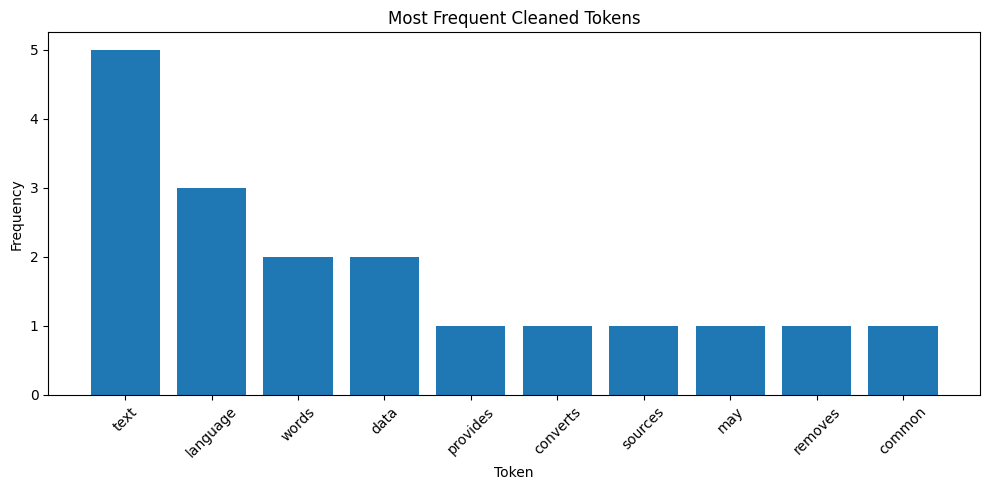

In [16]:
# Section 15 Python cell

top_df: pl.DataFrame = freq_df.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_df["token"], top_df["len"])

ax = plt.gca()
ax.tick_params(axis="x", labelrotation=45)

plt.title("Most Frequent Cleaned Tokens")
plt.xlabel("Token")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Section 16. Plot Token Counts Across Stages

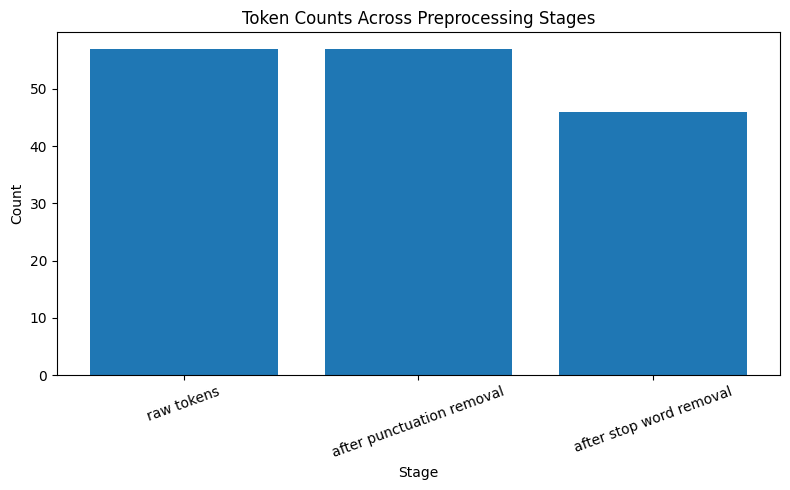

In [17]:
# Section 16 Python cell

plt.figure(figsize=(8, 5))
plt.bar(summary_df["stage"], summary_df["count"])

ax = plt.gca()
ax.tick_params(axis="x", labelrotation=20)

plt.title("Token Counts Across Preprocessing Stages")
plt.xlabel("Stage")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Section 17. Plot Top Bigrams

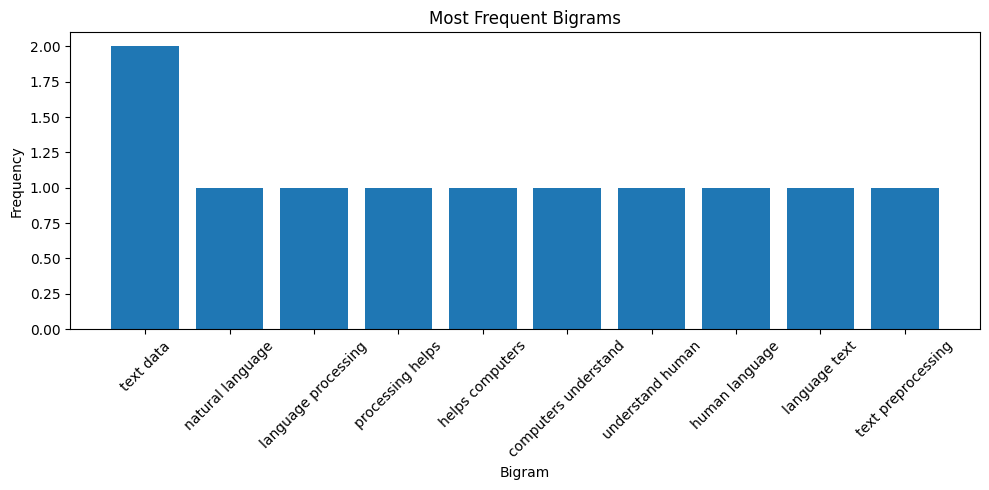

In [18]:
# Section 17 Python cell

top_bigram_df = bigram_df.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_bigram_df["bigram"], top_bigram_df["count"])

ax = plt.gca()
ax.tick_params(axis="x", labelrotation=45)

plt.title("Most Frequent Bigrams")
plt.xlabel("Bigram")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Section 18. Plot Business Categories

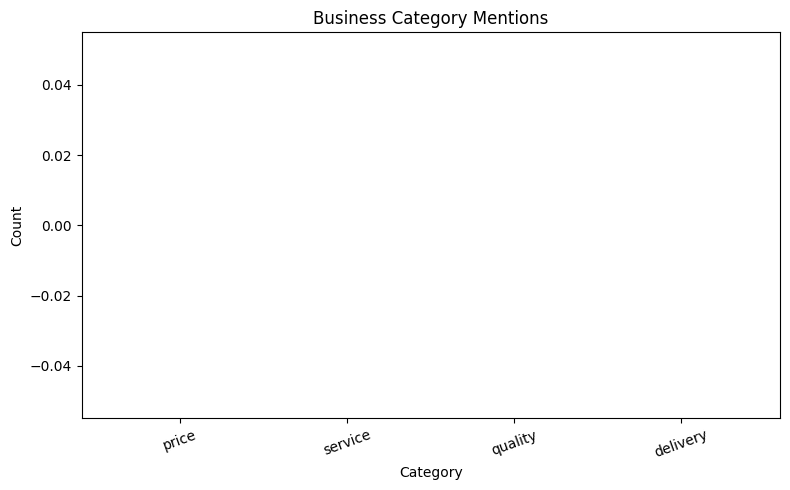

In [19]:
# Section 18 Python cell

plt.figure(figsize=(8, 5))
plt.bar(category_df["category"], category_df["count"])

ax = plt.gca()
ax.tick_params(axis="x", labelrotation=20)

plt.title("Business Category Mentions")
plt.xlabel("Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()